
Exploratory Data Analysis (EDA)
Customer Intelligence System - Country Data


In [47]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Set styling for better visuals
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


2.Load Dataset

In [48]:
df = pd.read_csv('../data/Country-data.csv')

In [49]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [50]:
print(df.isnull().sum())

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB


In [52]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [53]:
display(df.describe().T.round(2))

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.27,40.33,2.60,8.25,19.30,62.10,208.00
exports,167.0,41.11,27.41,0.11,23.80,35.00,51.35,200.00
health,167.0,6.82,2.75,1.81,4.92,6.32,8.60,17.90
imports,167.0,46.89,24.21,0.07,30.20,43.30,58.75,174.00
income,167.0,17144.69,19278.07,609.00,3355.00,9960.00,22800.00,125000.00
inflation,167.0,7.78,10.57,-4.21,1.81,5.39,10.75,104.00
life_expec,167.0,70.56,8.89,32.10,65.30,73.10,76.80,82.80
total_fer,167.0,2.95,1.51,1.15,1.80,2.41,3.88,7.49
gdpp,167.0,12964.16,18328.70,231.00,1330.00,4660.00,14050.00,105000.00


In [54]:
print('Columns:', df.columns.tolist())

Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


In [56]:
df = df.copy()
df.columns = [c.strip().lower() for c in df.columns]
df = df.drop_duplicates()

for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

numeric_cols = [c for c in df.columns if c != 'country']
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

df.isna().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

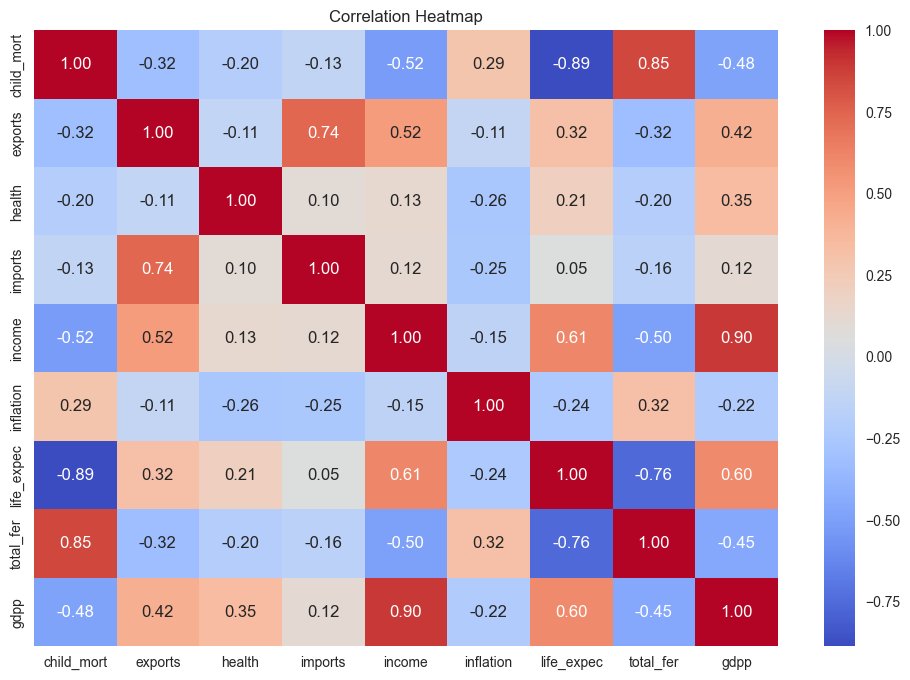

In [58]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

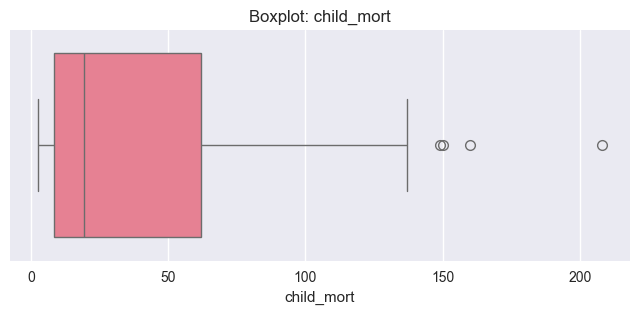

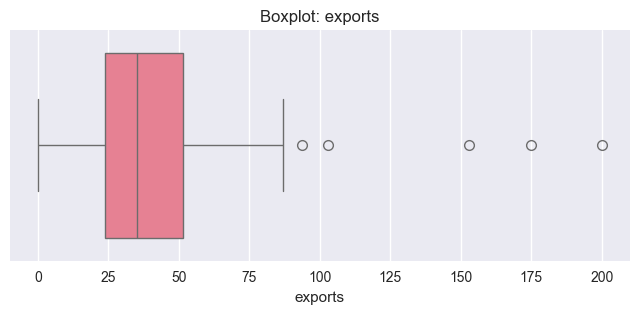

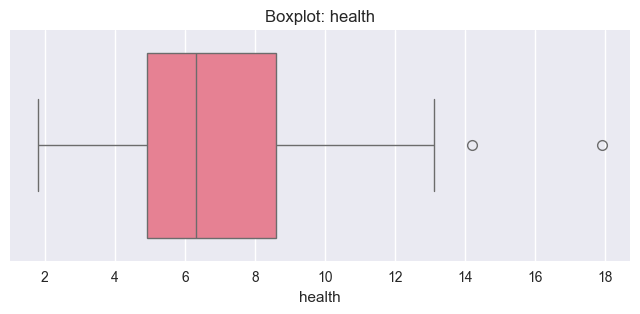

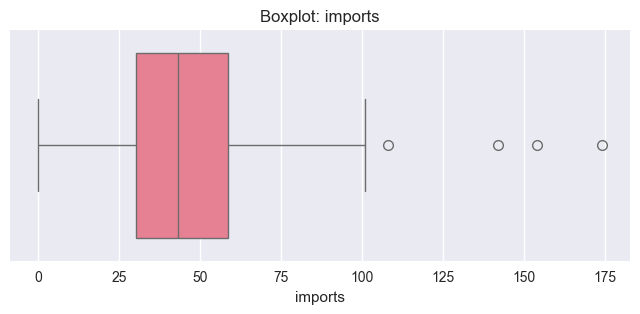

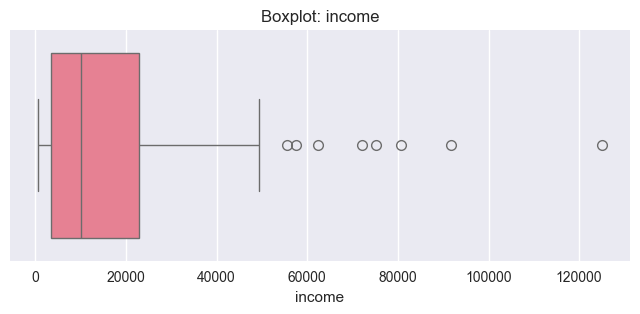

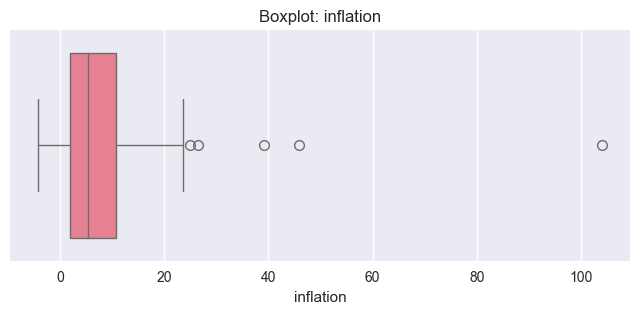

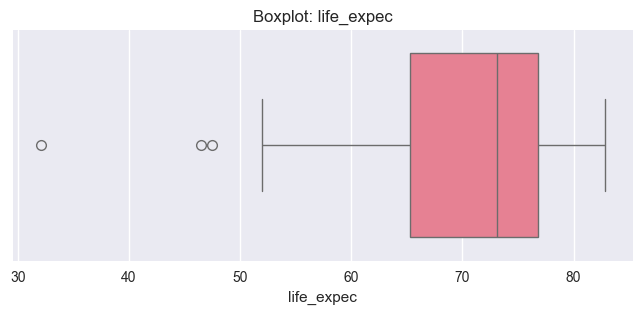

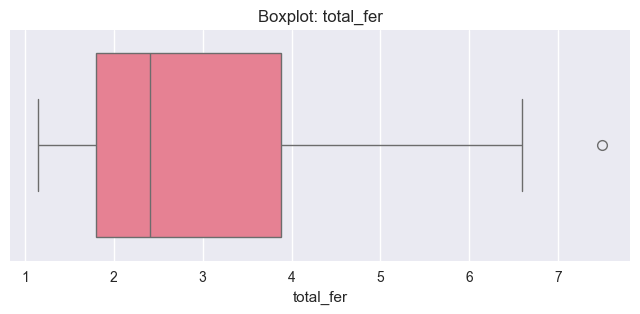

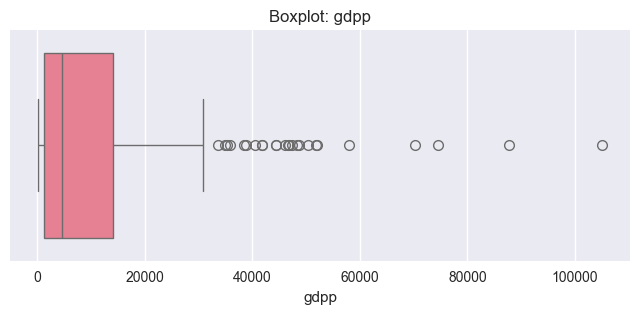

In [59]:
for col in numeric_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

In [41]:
features = df.drop(columns=['country'], errors='ignore')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
X_scaled.shape

(167, 9)

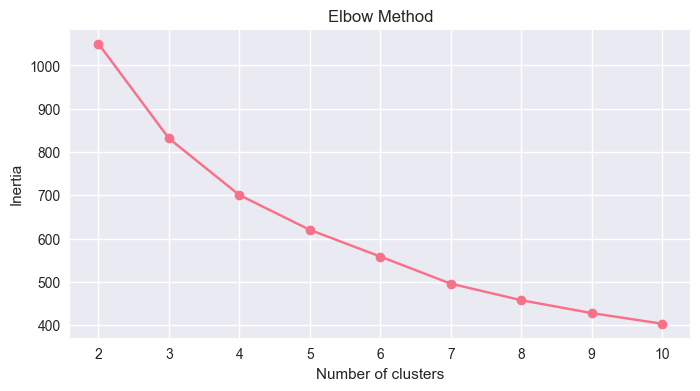

In [42]:
inertias = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [43]:
best_k = 3  # change after checking the elbow plot
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print('Silhouette Score:', silhouette_score(X_scaled, df['kmeans_cluster']))
df[['country', 'kmeans_cluster']].head() if 'country' in df.columns else df[['kmeans_cluster']].head()

Silhouette Score: 0.28329575683463126


,country,kmeans_cluster
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2


In [44]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

print(df['dbscan_cluster'].value_counts().sort_index())

dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64


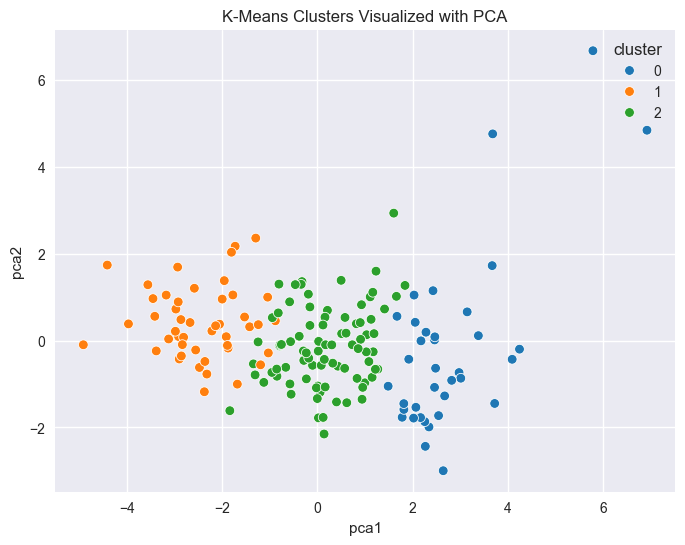

In [45]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

viz = pd.DataFrame({
    'pca1': X_pca[:, 0],
    'pca2': X_pca[:, 1],
    'cluster': df['kmeans_cluster']
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=viz, x='pca1', y='pca2', hue='cluster', palette='tab10')
plt.title('K-Means Clusters Visualized with PCA')
plt.show()

In [46]:
profile = df.groupby('kmeans_cluster')[numeric_cols].mean().round(2)
profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45
